Environment: velocity

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import single_cell_analysis

Packages required:
- Pyranges
- Pyfaidx

In [2]:
# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,transcript_status,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
0,GL456210.1,ENSEMBL,gene,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL456210.1,ENSEMBL,transcript,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,NaN,NaN,ENSMUSP00000106995.2,NaN,NaN
2,GL456210.1,ENSEMBL,exon,123791,123905,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
3,GL456210.1,ENSEMBL,CDS,123791,123905,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
4,GL456210.1,ENSEMBL,start_codon,123791,123794,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617650,chrY,ENSEMBL,exon,90838868,90839177,.,-,.,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617651,chrY,ENSEMBL,CDS,90838871,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617652,chrY,ENSEMBL,start_codon,90839174,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617653,chrY,ENSEMBL,stop_codon,90838868,90838871,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN


Description of the Narrowpeak format: https://macs3-project.github.io/MACS/docs/narrowPeak.html

In [3]:
# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

In [4]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)


In [29]:
# Closest gene method using middle of peak

def closest_gene(peaks, annotation, max_distance=1000000, use_center=True, nb_cpu=1):
    # Filter for protein-coding genes
    genes = annotation[annotation.Feature == "gene"]
    genes_df = genes.as_df()

    # Define the transcription start site based on the strand direction
    positive_strand = genes_df["Strand"] == "+"
    negative_strand = genes_df["Strand"] == "-"
    genes_df.loc[positive_strand, "End"] = genes_df.loc[positive_strand, "Start"]
    genes_df.loc[negative_strand, "Start"] = genes_df.loc[negative_strand, "End"]
    tss_positions = pyranges.PyRanges(genes_df)

    # Find the center of each peak
    peak_center = (peaks.df["Start"] + peaks.df["End"]) / 2.0
    if use_center:
        peaks_df = peaks.as_df()
        peaks_df["Start"] = peak_center
        peaks_df["End"] = peak_center
        peaks = pyranges.PyRanges(peaks_df)

    # Find the closest TSS to each peak
    closest_tss = peaks.nearest(tss_positions, nb_cpu=nb_cpu)

    # Filter distances that are too large
    filtered_indices = (closest_tss.df["Distance"] < max_distance).to_list()
    closest_tss_df = closest_tss.as_df()[filtered_indices]
    peak_center = peak_center[filtered_indices]

    # Check if peak is upstream or downstream
    # If the peak center is exactly at the TSS, the gene will be considered upstream
    is_positive = closest_tss_df["Strand_b"] == "+"
    is_negative = closest_tss_df["Strand_b"] == "-"
    tss_position = closest_tss_df["Start_b"]
    closest_tss_df["Upstream"] = False
    closest_tss_df["Downstream"] = False
    # Upstream peaks
    closest_tss_df.loc[is_positive & (peak_center <= tss_position), "Upstream"] = True
    closest_tss_df.loc[is_negative & (peak_center >= tss_position), "Upstream"] = True
    # Downstream peaks
    closest_tss_df.loc[is_negative & (peak_center < tss_position), "Downstream"] = True
    closest_tss_df.loc[is_positive & (peak_center > tss_position), "Downstream"] = True

    # Get up- and downstream distribution
    upstream_indices = closest_tss_df["Upstream"]
    downstream_indices = closest_tss_df["Downstream"]
    upstream_distribution = closest_tss_df[upstream_indices]["Distance"].to_numpy()
    upstream_distribution.sort()
    downstream_distribution = closest_tss_df[downstream_indices]["Distance"].to_numpy()
    downstream_distribution.sort()

    # Score each peak based on distance distribution
    distances = closest_tss_df["Distance"]
    peak_scores = numpy.zeros_like(distances, dtype=float)
    peak_scores[upstream_indices] = [-numpy.log10((numpy.argmax(upstream_distribution == distance)+1)/len(upstream_distribution)) for distance in distances[upstream_indices]]
    peak_scores[downstream_indices] = [-numpy.log10((numpy.argmax(downstream_distribution == distance)+1)/len(downstream_distribution)) for distance in distances[downstream_indices]]
    closest_tss_df["Peak_score"] = peak_scores

    # Score each gene
    gene_scores = closest_tss_df.groupby("gene_name")["Peak_score"].sum().reset_index()
    gene_scores.index = gene_scores["gene_name"]
    gene_scores = gene_scores.drop(columns="gene_name")
    gene_scores = gene_scores.rename(columns={"Peak_score": "chip_score"})

    # Give genes without peaks a score of 0
    all_genes = genes_df["gene_name"].unique()
    gene_scores = gene_scores.reindex(all_genes, fill_value=0.0)
    gene_scores = gene_scores.sort_values("chip_score", ascending=False)

    return gene_scores

In [30]:
hic2_target_scores = closest_gene(hic2_peaks, annotation, use_center=True, max_distance=1000000)

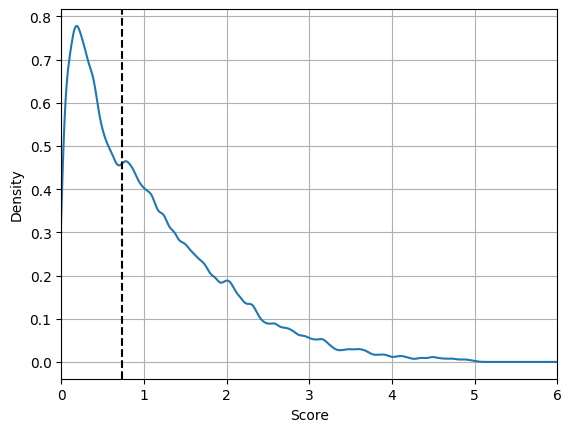

In [42]:
hic2_target_scores.query("chip_score>0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.73
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()

There are two peaks, where the second likely corresponds to true targets. A cutoff at 0.75 was chosen since this is just before the peak, meaning most true positives are found while minimizing unnecessary false positives.

In [43]:
hic2_targets = hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(hic2_targets)} Hic2 targets")

Found 11607 Hic2 targets


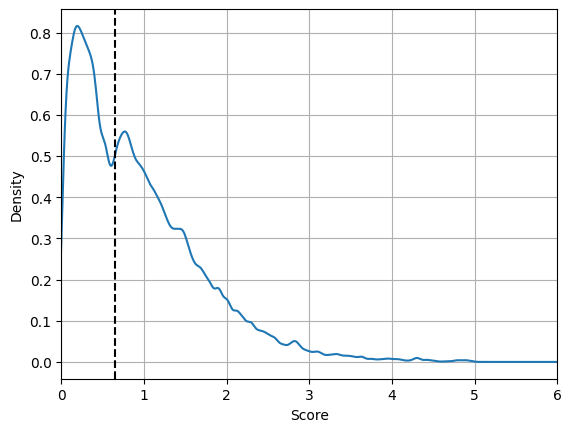

Found 12340 targets for Klf4 with Hic2 overexpression


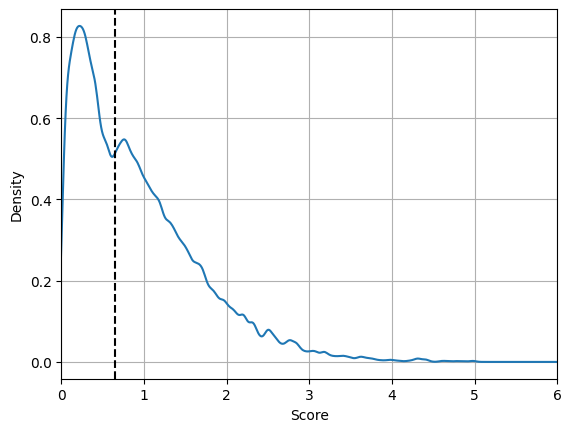

Found 12101 targets for Klf4 without Hic2 overexpression


In [45]:
# Find Klf4 targets with and without Hic2 overexpression

klf4_hic2_target_scores = closest_gene(klf4_hic2_peaks, annotation, use_center=True, max_distance=1000000)
klf4_hic2_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_hic2_targets = klf4_hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_target_scores = closest_gene(klf4_control_peaks, annotation, use_center=True, max_distance=1000000)
klf4_control_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_control_targets = klf4_control_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

A cutoff of 0.7 is just before the second peak for both Klf4 experiments.

In [46]:
# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 10717 overlapping Klf4 targets
Found 8842 shared targets


In [47]:
# Save targets to disk

base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores.to_csv(f"{base_name}_hic2_scores.csv")
klf4_hic2_target_scores.to_csv(f"{base_name}_klf4_hic2_scores.csv")
klf4_control_target_scores.to_csv(f"{base_name}_klf4_control_scores.csv")

numpy.savetxt(f"{base_name}_hic2_targets.txt", hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_hic2_targets.txt", klf4_hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_control_targets.txt", klf4_control_targets, fmt="%s")

# Comparison to Cellrank data

In [48]:
# Compare to cellrank data

# Read saved objects from Cellrank analysis
working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)

In [70]:
variable_genes = adata.var_names.to_numpy()
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100).index.to_numpy()

In [50]:
driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Cd24a,0.666657,0.000000e+00,0.000000e+00,0.655367,0.677649,-0.666674,0.000000e+00,0.000000e+00,-0.677665,-0.655385
Lmo1,0.592961,0.000000e+00,0.000000e+00,0.579805,0.605808,-0.592961,0.000000e+00,0.000000e+00,-0.605808,-0.579804
Crip2,0.576532,0.000000e+00,0.000000e+00,0.562990,0.589764,-0.576541,0.000000e+00,0.000000e+00,-0.589773,-0.563000
Lgals7,0.573921,0.000000e+00,0.000000e+00,0.560320,0.587214,-0.573918,0.000000e+00,0.000000e+00,-0.587211,-0.560316
Ctsz,0.573301,0.000000e+00,0.000000e+00,0.559685,0.586607,-0.573331,0.000000e+00,0.000000e+00,-0.586637,-0.559715
...,...,...,...,...,...,...,...,...,...,...
Myc,0.350730,1.047912e-280,1.056910e-279,0.333022,0.368190,-0.350729,1.049793e-280,1.058806e-279,-0.368190,-0.333022
Tob1,0.345602,6.672769e-272,6.468699e-271,0.327825,0.363135,-0.345601,6.712714e-272,6.507422e-271,-0.363134,-0.327823
Map1b,0.345115,4.481674e-271,4.323624e-270,0.327331,0.362655,-0.345115,4.483803e-271,4.325678e-270,-0.362655,-0.327331


In [71]:
# Find which driver genes are targets for Hic2

hic2_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, hic2_targets)
hic2_dead_end_drivers = numpy.intersect1d(dead_end_drivers, hic2_targets)

In [72]:
hic2_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Arrdc4', 'Atp1b1',
       'Calcoco2', 'Car2', 'Ccnb2', 'Cenpm', 'Cited2', 'Col18a1',
       'Cox7a1', 'Dhx16', 'Dnmt3b', 'Fgf4', 'Fgfbp1', 'Fn1', 'Fxyd6',
       'Gpx4', 'Hmgn2', 'Hspb1', 'Ifitm1', 'Jarid2', 'Klf2', 'L1td1',
       'Mdk', 'Msh6', 'Mtf2', 'Mylpf', 'Phc1', 'Rbpms2', 'Rest', 'Rif1',
       'Slc2a3', 'Sparc', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tmsb10', 'Trim71',
       'Txnip', 'Ucp2', 'Wfdc2', 'Zfp42', 'Zfp462'], dtype=object)

In [73]:
hic2_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa8', 'Avil', 'B2m', 'Bspry', 'Cbr3',
       'Ccnd1', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1', 'Cisd3',
       'Crip2', 'Ctsb', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dmrtc2', 'Dsp', 'Emp2',
       'Emp3', 'Fabp5', 'Fam195a', 'Fkbp11', 'Gatm', 'Gch1', 'Ggh',
       'Gsto1', 'Ifi30', 'Ifrd1', 'Isyna1', 'Kcnn4', 'Krt13', 'Krt8',
       'Lad1', 'Lgals7', 'Lmna', 'Lmo1', 'Ly6g6c', 'Mal', 'Mal2', 'Map1b',
       'Mgst3', 'Misp', 'Myc', 'Myl7', 'Nradd', 'Nrip3', 'Nupr1', 'Ovol1',
       'Pcolce', 'Pcolce2', 'Perp', 'Pkp1', 'Pla2g12a', 'Plek2', 'Prkaa2',
       'Prr13', 'Psmb10', 'Ptprv', 'Rac3', 'Rtn4r', 'S100a14', 'S100a16',
       'Sat1', 'Serpinb6c', 'Shisa8', 'Shtn1', 'Smagp', 'Smpdl3a',
       'Spink2', 'Spint2', 'Taok3', 'Tlx2', 'Tmem238', 'Tnfrsf13c',
       'Tob1', 'Tppp3', 'Trim47', 'Tubb3', 'Urah', 'Zbtb7c'], dtype=object)

In [74]:
# Overlapping Klf4 targets
klf4_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, klf4_targets)
klf4_dead_end_drivers = numpy.intersect1d(dead_end_drivers, klf4_targets)

In [75]:
klf4_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Aire', 'Arl6ip1',
       'Arrdc4', 'Atp1b1', 'Calcoco2', 'Car2', 'Ccnb2', 'Cd59a', 'Cenpm',
       'Cited2', 'Cotl1', 'Cox7a1', 'Dlc1', 'Dnmt3b', 'Fn1', 'Fxyd6',
       'Gpx4', 'H2afv', 'Hmgb2', 'Hspb1', 'Jarid2', 'Klf2', 'Klhl13',
       'L1td1', 'Lrpap1', 'Mdk', 'Msh6', 'Mtf2', 'Nedd4', 'Phc1',
       'Rbpms2', 'Rdm1', 'Rest', 'Rif1', 'Slc2a3', 'Sparc', 'Suz12',
       'Syce2', 'Tcea3', 'Tcf7l1', 'Tdgf1', 'Tmsb10', 'Trim71', 'Txnip',
       'Ucp2', 'Zfp42', 'Zfp462'], dtype=object)

In [76]:
klf4_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa8', 'B2m', 'Bspry', 'Cbr3', 'Ccnd1',
       'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1', 'Chst13', 'Cisd3',
       'Crip2', 'Ctsb', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dsp', 'Emp2', 'Emp3',
       'Fabp5', 'Fam195a', 'Gatm', 'Gch1', 'Ggh', 'Gsto1', 'Homer2',
       'Ifi30', 'Isyna1', 'Kcnn4', 'Kiss1r', 'Krt13', 'Krt14', 'Krt8',
       'Lad1', 'Lgals7', 'Lmna', 'Lmo1', 'Ly6g6c', 'Mal', 'Mgst3', 'Misp',
       'Myc', 'Myl7', 'Nradd', 'Nupr1', 'Obsl1', 'Ovol1', 'Pcolce',
       'Pcolce2', 'Perp', 'Pkp1', 'Plek2', 'Prkaa2', 'Prr13', 'Ptprv',
       'Rac3', 'Rtn4r', 'S100a1', 'S100a14', 'S100a16', 'Sat1', 'Shisa8',
       'Shtn1', 'Smagp', 'Smpdl3a', 'Spink2', 'Spint2', 'Taok3', 'Tlx2',
       'Tnfrsf13c', 'Tob1', 'Tppp3', 'Trim47', 'Tubb3', 'Urah', 'Zbtb7c'],
      dtype=object)

In [77]:
# Shared stem cell drivers
shared_stem_cell_drivers = numpy.intersect1d(hic2_stem_cell_drivers, klf4_stem_cell_drivers)
shared_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Arrdc4', 'Atp1b1',
       'Calcoco2', 'Car2', 'Ccnb2', 'Cenpm', 'Cited2', 'Cox7a1', 'Dnmt3b',
       'Fn1', 'Fxyd6', 'Gpx4', 'Hspb1', 'Jarid2', 'Klf2', 'L1td1', 'Mdk',
       'Msh6', 'Mtf2', 'Phc1', 'Rbpms2', 'Rest', 'Rif1', 'Slc2a3',
       'Sparc', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tmsb10', 'Trim71', 'Txnip',
       'Ucp2', 'Zfp42', 'Zfp462'], dtype=object)

In [78]:
# Shared dead end drivers
shared_dead_end_drivers = numpy.intersect1d(hic2_dead_end_drivers, klf4_dead_end_drivers)
shared_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa8', 'B2m', 'Bspry', 'Cbr3', 'Ccnd1',
       'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1', 'Cisd3', 'Crip2',
       'Ctsb', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dsp', 'Emp2', 'Emp3', 'Fabp5',
       'Fam195a', 'Gatm', 'Gch1', 'Ggh', 'Gsto1', 'Ifi30', 'Isyna1',
       'Kcnn4', 'Krt13', 'Krt8', 'Lad1', 'Lgals7', 'Lmna', 'Lmo1',
       'Ly6g6c', 'Mal', 'Mgst3', 'Misp', 'Myc', 'Myl7', 'Nradd', 'Nupr1',
       'Ovol1', 'Pcolce', 'Pcolce2', 'Perp', 'Pkp1', 'Plek2', 'Prkaa2',
       'Prr13', 'Ptprv', 'Rac3', 'Rtn4r', 'S100a14', 'S100a16', 'Sat1',
       'Shisa8', 'Shtn1', 'Smagp', 'Smpdl3a', 'Spink2', 'Spint2', 'Taok3',
       'Tlx2', 'Tnfrsf13c', 'Tob1', 'Tppp3', 'Trim47', 'Tubb3', 'Urah',
       'Zbtb7c'], dtype=object)

The most interesting shared targets among the dead end drivers are:
- Genes involved in epithelial cell differentiation: KRT17;KRT16;KRT13;OVOL1;CTSB
- Genes involved in epidermal development: CRABP2;FABP5;KLK14;OVOL1

Especially Ovol1 and the keratin genes are relevant. Ovol1 promotes mesenchymal-to-epithelial transition

The most interesting stem cell drivers are:
- Genes regulating epithelial to mesenchymal transition: EPHA4;TCF7L2;SFRP1;MDK;GLIPR2

Mdk is especially interesting as a driver of EMT with interesting expression trends.

# Check which driver targets are transcription factors

Source for list of transcription factors: https://guolab.wchscu.cn/AnimalTFDB#!/download

In [129]:
tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [130]:
# Dead end drivers which are TFs

shared_dead_end_tfs = numpy.intersect1d(shared_dead_end_drivers, tf_array)
driver_df.loc[shared_dead_end_tfs].sort_values("Day 12 Control_corr", ascending=False)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Tlx2,0.480197,0.000000e+00,0.000000e+00,0.464621,0.495476,-0.480199,0.000000e+00,0.000000e+00,-0.495478,-0.464623
Ovol1,0.445422,0.000000e+00,0.000000e+00,0.429206,0.461352,-0.445423,0.000000e+00,0.000000e+00,-0.461352,-0.429207
Zbtb7c,0.356456,9.486903e-291,9.919029e-290,0.338829,0.373834,-0.356446,9.912683e-291,1.036420e-289,-0.373823,-0.338818
Myc,0.350730,1.047912e-280,1.056910e-279,0.333022,0.368190,-0.350729,1.049793e-280,1.058806e-279,-0.368190,-0.333022


In [131]:
# Hic2 targets instead of shared targets

hic2_dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
driver_df.loc[hic2_dead_end_tfs].sort_values("Day 12 Control_corr", ascending=False)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Tlx2,0.480197,0.000000e+00,0.000000e+00,0.464621,0.495476,-0.480199,0.000000e+00,0.000000e+00,-0.495478,-0.464623
Ovol1,0.445422,0.000000e+00,0.000000e+00,0.429206,0.461352,-0.445423,0.000000e+00,0.000000e+00,-0.461352,-0.429207
Dmrtc2,0.443900,0.000000e+00,0.000000e+00,0.427656,0.459856,-0.443898,0.000000e+00,0.000000e+00,-0.459855,-0.427655
Zbtb7c,0.356456,9.486903e-291,9.919029e-290,0.338829,0.373834,-0.356446,9.912683e-291,1.036420e-289,-0.373823,-0.338818
Myc,0.350730,1.047912e-280,1.056910e-279,0.333022,0.368190,-0.350729,1.049793e-280,1.058806e-279,-0.368190,-0.333022


Ovol1 is the most interesting target. Cdh1 also looks like it could be a Hic2 target, but the narrowpeak file has removed the peak, likely due to a low q-value. The narrowpeak also does not list the peak for Klf4 even though it is a known target of Klf4.

In [132]:
# Stem cell drivers which are TFs

shared_stem_cell_tfs = numpy.intersect1d(shared_stem_cell_drivers, tf_array)
driver_df.loc[shared_stem_cell_tfs].sort_values("Day 12 Control_corr", ascending=True)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.501349,0.000000e+00,0.000000e+00,-0.516210,-0.486187,0.501354,0.000000e+00,0.000000e+00,0.486192,0.516215
Zfp42,-0.463796,0.000000e+00,0.000000e+00,-0.479388,-0.447912,0.463805,0.000000e+00,0.000000e+00,0.447921,0.479396
Tcf7l1,-0.431043,0.000000e+00,0.000000e+00,-0.447227,-0.414576,0.431038,0.000000e+00,0.000000e+00,0.414572,0.447222
Rest,-0.383284,0.000000e+00,0.000000e+00,-0.400257,-0.366048,0.383292,0.000000e+00,0.000000e+00,0.366056,0.400265
Klf2,-0.364566,2.328490e-305,2.597762e-304,-0.381824,-0.347053,0.364567,2.319055e-305,2.587237e-304,0.347054,0.381825


In [133]:
# Stem cell drivers which are TFs

hic2_stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
driver_df.loc[hic2_stem_cell_tfs].sort_values("Day 12 Control_corr", ascending=True)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.501349,0.000000e+00,0.000000e+00,-0.516210,-0.486187,0.501354,0.000000e+00,0.000000e+00,0.486192,0.516215
Zfp42,-0.463796,0.000000e+00,0.000000e+00,-0.479388,-0.447912,0.463805,0.000000e+00,0.000000e+00,0.447921,0.479396
Tcf7l1,-0.431043,0.000000e+00,0.000000e+00,-0.447227,-0.414576,0.431038,0.000000e+00,0.000000e+00,0.414572,0.447222
Rest,-0.383284,0.000000e+00,0.000000e+00,-0.400257,-0.366048,0.383292,0.000000e+00,0.000000e+00,0.366056,0.400265
Klf2,-0.364566,2.328490e-305,2.597762e-304,-0.381824,-0.347053,0.364567,2.319055e-305,2.587237e-304,0.347054,0.381825


Jarid2 is a strong driver that regulates differentiation of stem cells.

In [134]:
# Hic2 target TFs that are dead end drivers

dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
dead_end_tfs

array(['Dmrtc2', 'Myc', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

In [135]:
# Hic2 target TFs that are stem cell drivers

stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
stem_cell_tfs

array(['Jarid2', 'Klf2', 'Rest', 'Tcf7l1', 'Zfp42'], dtype=object)

In [136]:
# Find all Hic2 targets that are transcription factors among the variable genes

hic2_target_tfs = numpy.intersect1d(hic2_targets, tf_array)
variable_hic2_target_tfs = numpy.intersect1d(hic2_target_tfs, adata.var_names.to_numpy())
variable_hic2_target_tfs

array(['Arid3a', 'Atf5', 'Barx2', 'Creb3l1', 'Creb3l2', 'Dbp', 'Ddit3',
       'Dmrtc2', 'Egr1', 'Ehf', 'En1', 'Fos', 'Fosb', 'Fosl1', 'Fosl2',
       'Foxp2', 'Gata2', 'Gata6', 'Hand1', 'Hic2', 'Hmga2', 'Hmgb3',
       'Hopx', 'Hoxa10', 'Hoxa7', 'Hoxb9', 'Id2', 'Id3', 'Irx1', 'Irx3',
       'Jarid2', 'Junb', 'Klf10', 'Klf2', 'Klf4', 'Klf5', 'Klf6', 'Klf7',
       'Lhx9', 'Lin28a', 'Meis2', 'Meox2', 'Msc', 'Myc', 'Mycn', 'Nfil3',
       'Nfix', 'Nr2f1', 'Nr4a1', 'Ovol1', 'Pax8', 'Peg3', 'Phox2a',
       'Pou5f1', 'Prrx1', 'Prrx2', 'Rest', 'Runx1', 'Sall1', 'Setbp1',
       'Smad7', 'Snai2', 'Sox9', 'Stat2', 'Tbx3', 'Tcf4', 'Tcf7l1',
       'Tcf7l2', 'Tfap2c', 'Tfcp2l1', 'Tfdp2', 'Tlx2', 'Tlx3', 'Tox',
       'Tsc22d1', 'Tshz1', 'Tshz2', 'Twist1', 'Twist2', 'Zbtb20',
       'Zbtb7c', 'Zeb2', 'Zfat', 'Zfhx3', 'Zfp296', 'Zfp36l1', 'Zfp42',
       'Zfp503', 'Zfp710', 'Zim1', 'Zmiz1'], dtype=object)

In [137]:
# Find all shared targets that are transcription factors among the variable genes

shared_target_tfs = numpy.intersect1d(shared_targets, tf_array)
variable_shared_target_tfs = numpy.intersect1d(shared_target_tfs, adata.var_names.to_numpy())
variable_shared_target_tfs

array(['Arid3a', 'Atf5', 'Barx2', 'Creb3l1', 'Creb3l2', 'Dbp', 'Ddit3',
       'Egr1', 'Ehf', 'En1', 'Fos', 'Fosb', 'Fosl1', 'Fosl2', 'Gata2',
       'Gata6', 'Hic2', 'Hmga2', 'Hoxa7', 'Hoxb9', 'Id2', 'Id3', 'Irx1',
       'Irx3', 'Jarid2', 'Junb', 'Klf10', 'Klf2', 'Klf4', 'Klf5', 'Klf7',
       'Lhx9', 'Lin28a', 'Msc', 'Myc', 'Mycn', 'Nfil3', 'Nfix', 'Nr2f1',
       'Nr4a1', 'Ovol1', 'Peg3', 'Phox2a', 'Pou5f1', 'Prrx1', 'Rest',
       'Sall1', 'Setbp1', 'Smad7', 'Snai2', 'Stat2', 'Tbx3', 'Tcf4',
       'Tcf7l1', 'Tcf7l2', 'Tfap2c', 'Tfcp2l1', 'Tfdp2', 'Tlx2', 'Tlx3',
       'Tox', 'Tsc22d1', 'Tshz1', 'Tshz2', 'Twist1', 'Twist2', 'Zbtb20',
       'Zbtb7c', 'Zeb2', 'Zfat', 'Zfhx3', 'Zfp296', 'Zfp36l1', 'Zfp42',
       'Zfp503', 'Zfp710', 'Zim1', 'Zmiz1'], dtype=object)

In [138]:
# Rank all Hic2 targets by correlation with cell fates

# Top dead end drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Day 12 Control_corr", ascending=False).query("`Day 12 Control_corr` > 0")

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Tlx2,0.480197,0.000000e+00,0.000000e+00,0.464621,0.495476,-0.480199,0.000000e+00,0.000000e+00,-0.495478,-0.464623
Ovol1,0.445422,0.000000e+00,0.000000e+00,0.429206,0.461352,-0.445423,0.000000e+00,0.000000e+00,-0.461352,-0.429207
Dmrtc2,0.443900,0.000000e+00,0.000000e+00,0.427656,0.459856,-0.443898,0.000000e+00,0.000000e+00,-0.459855,-0.427655
Zbtb7c,0.356456,9.486903e-291,9.919029e-290,0.338829,0.373834,-0.356446,9.912683e-291,1.036420e-289,-0.373823,-0.338818
Myc,0.350730,1.047912e-280,1.056910e-279,0.333022,0.368190,-0.350729,1.049793e-280,1.058806e-279,-0.368190,-0.333022
Phox2a,0.309993,1.778760e-215,1.345524e-214,0.291757,0.328003,-0.309992,1.781016e-215,1.347230e-214,-0.328003,-0.291756
Hmgb3,0.253099,4.268599e-141,2.169056e-140,0.234238,0.271769,-0.253110,4.146575e-141,2.107051e-140,-0.271780,-0.234249
Tshz1,0.221100,5.088638e-107,2.117086e-106,0.201946,0.240085,-0.221095,5.141184e-107,2.138947e-106,-0.240080,-0.201941
Barx2,0.218176,3.621180e-104,1.469816e-103,0.198997,0.237187,-0.218176,3.620618e-104,1.469588e-103,-0.237187,-0.198997


In [139]:
# Top stem cell drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Day 12 Control_corr", ascending=True).query("`Day 12 Control_corr` < 0")

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.501349,0.000000e+00,0.000000e+00,-0.516210,-0.486187,0.501354,0.000000e+00,0.000000e+00,0.486192,0.516215
Zfp42,-0.463796,0.000000e+00,0.000000e+00,-0.479388,-0.447912,0.463805,0.000000e+00,0.000000e+00,0.447921,0.479396
Tcf7l1,-0.431043,0.000000e+00,0.000000e+00,-0.447227,-0.414576,0.431038,0.000000e+00,0.000000e+00,0.414572,0.447222
Rest,-0.383284,0.000000e+00,0.000000e+00,-0.400257,-0.366048,0.383292,0.000000e+00,0.000000e+00,0.366056,0.400265
Klf2,-0.364566,2.328490e-305,2.597762e-304,-0.381824,-0.347053,0.364567,2.319055e-305,2.587237e-304,0.347054,0.381825
Mycn,-0.327302,6.777349e-242,5.783917e-241,-0.345086,-0.309282,0.327301,6.785159e-242,5.790582e-241,0.309282,0.345086
Sall1,-0.302644,8.128951e-205,5.860475e-204,-0.320747,-0.284320,0.302645,8.105013e-205,5.843217e-204,0.284321,0.320748
Tfcp2l1,-0.301140,1.127831e-202,8.015224e-202,-0.319262,-0.282798,0.301141,1.123890e-202,7.987216e-202,0.282799,0.319263
Tsc22d1,-0.290928,1.740546e-188,1.166399e-187,-0.309174,-0.272469,0.290925,1.757936e-188,1.178053e-187,0.272465,0.309171


## Trends of transcription factors

In [140]:
# Define colors for all three groups

group_colors = [
    "#cbc9ca",
    "#0a652c",
    "#da2e24",
    "#3180bd",
]

adata.uns["group_colors"] = group_colors

control_indices = adata.obs["group"] == "control"
hic2_indices = adata.obs["group"] == "Hic2"
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

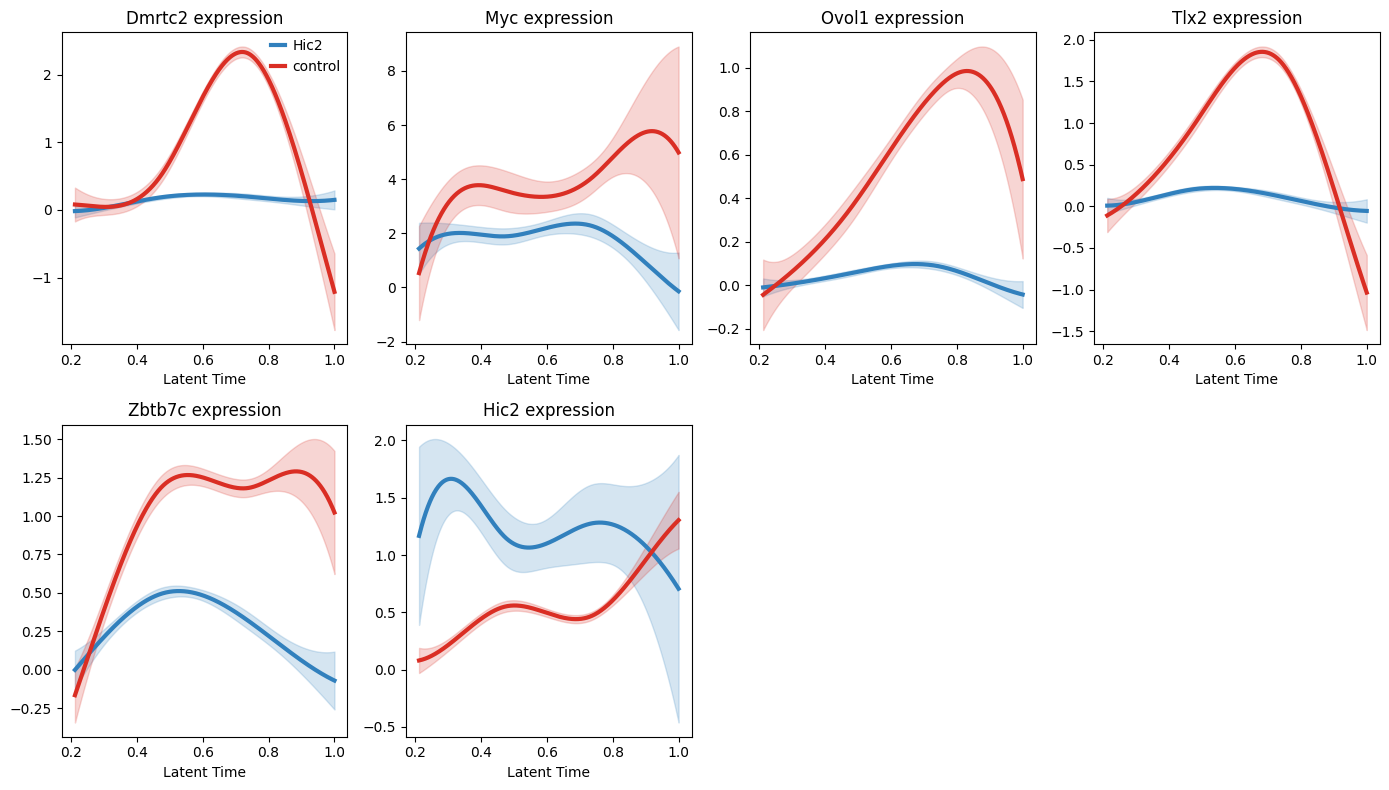

In [141]:
# Expression of dead end drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata, 
    list(dead_end_tfs)+ ["Hic2"], 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

Ovol1, Cdh1, Tlx2, Zbtb7c and Hmgb3 have the largest differences in expression between the groups. Once again, Ovol1 looks most promising. Hoxa7 does not look like a driver since it changes late in the process where some control cells reach the dead end. Myc is repressed by Ovol1, but is also a target of Hic2. If Hic2 downregulates Myc, Hic2 reprogramming could benefit from more Myc OX.

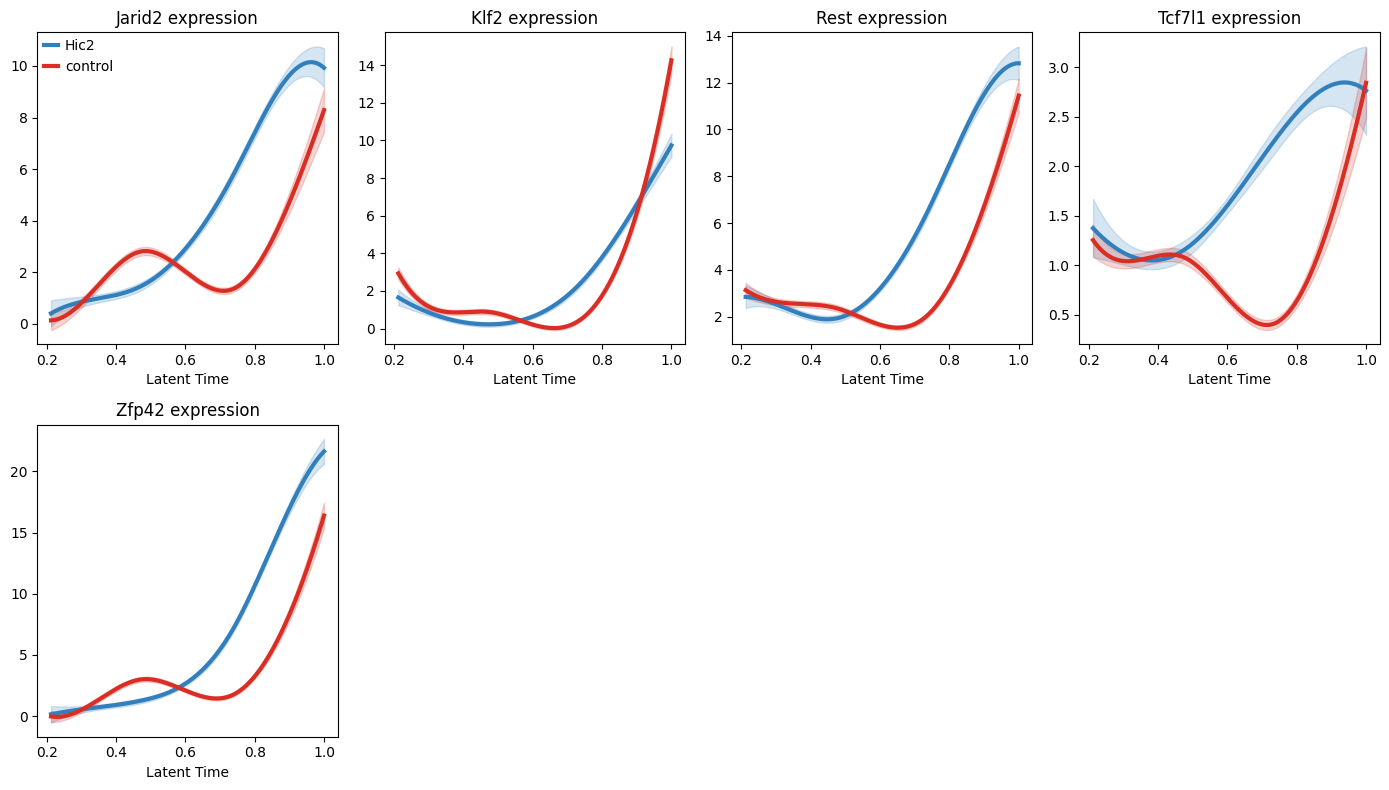

In [142]:
# Expression of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    stem_cell_tfs,
    group_key="group",
    layer="spliced",
    groups=["Hic2", "control"]
)

Jarid2, Tcf7l1, Rest and Tcf7l2 have the most interesting trends, but unlike the dead end drivers many only have differential expression later in during the process.

To do: Look at changes in transcription factor activity instead of mRNA levels. Below is a start for this

In [166]:
import gseapy as gp
import pandas as pd
import decoupler as dc

def load_enrichr_as_network(library_name):
    # 1. Download the library using GSEApy
    # Returns a dictionary: {'Term_Name': ['GeneA', 'GeneB', ...]}
    gs_dict = gp.get_library(name=library_name, organism='Mouse')
    
    network_list = []
    
    for term, genes in gs_dict.items():
        # The term usually looks like "KLF4 DOWN ..." or "KLF4_MOUSE_..."
        # We need to extract the TF name. 
        # CAUTION: This splitting depends on the specific naming convention of the library
        # For 'TF_Perturbations_Followed_by_Expression', format is often "TF_Perturbation_Direction"
        # We will attempt to grab the first word as the TF name
        if library_name in {"PerturbSeq_ReplogleK562", "PerturbSeq_ReplogleRPE1"}:
            tf_name = term.split()[1].upper()
        else:
            tf_name = term.split()[0].split('_')[0].upper() 
        
        for gene in genes:
            network_list.append({
                'source': tf_name,
                'target': gene,
                'weight': 1.0,      # We assume all targets are equal
                'collection': term  # Keep original term just in case
            })
            
    return pd.DataFrame(network_list)

In [167]:
# Use consensus network instead that also uses ChipSeq and motif data. Has Jarid in addition to the ones in TF_Perturbations_Followed_by_Expression,
# but gives values that do not work with Cellrank's gene_trends function
import decoupler as dc
net = dc.op.collectri(organism='mouse')

In [168]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-03-03 09:51:03 | [INFO] ulm - Running ulm
2026-03-03 09:51:03 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)


2026-03-03 09:51:03 | [INFO] Network adjacency matrix has 1111 unique features and 459 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-03-03 09:51:03 | [INFO] ulm - fitting 459 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-03-03 09:51:04 | [INFO] ulm - adjusting p-values by FDR
2026-03-03 09:51:04 | [INFO] ulm - done


In [126]:
# Activity of interesting genes

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

TypeError: plot_grouped_gene_trend() got an unexpected keyword argument 'obsm'

In [112]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

NameError: name 'plot_grouped_gene_trend' is not defined

Ovol1 activity is surprisingly higher in Hic2 cells, despite much lower expression.

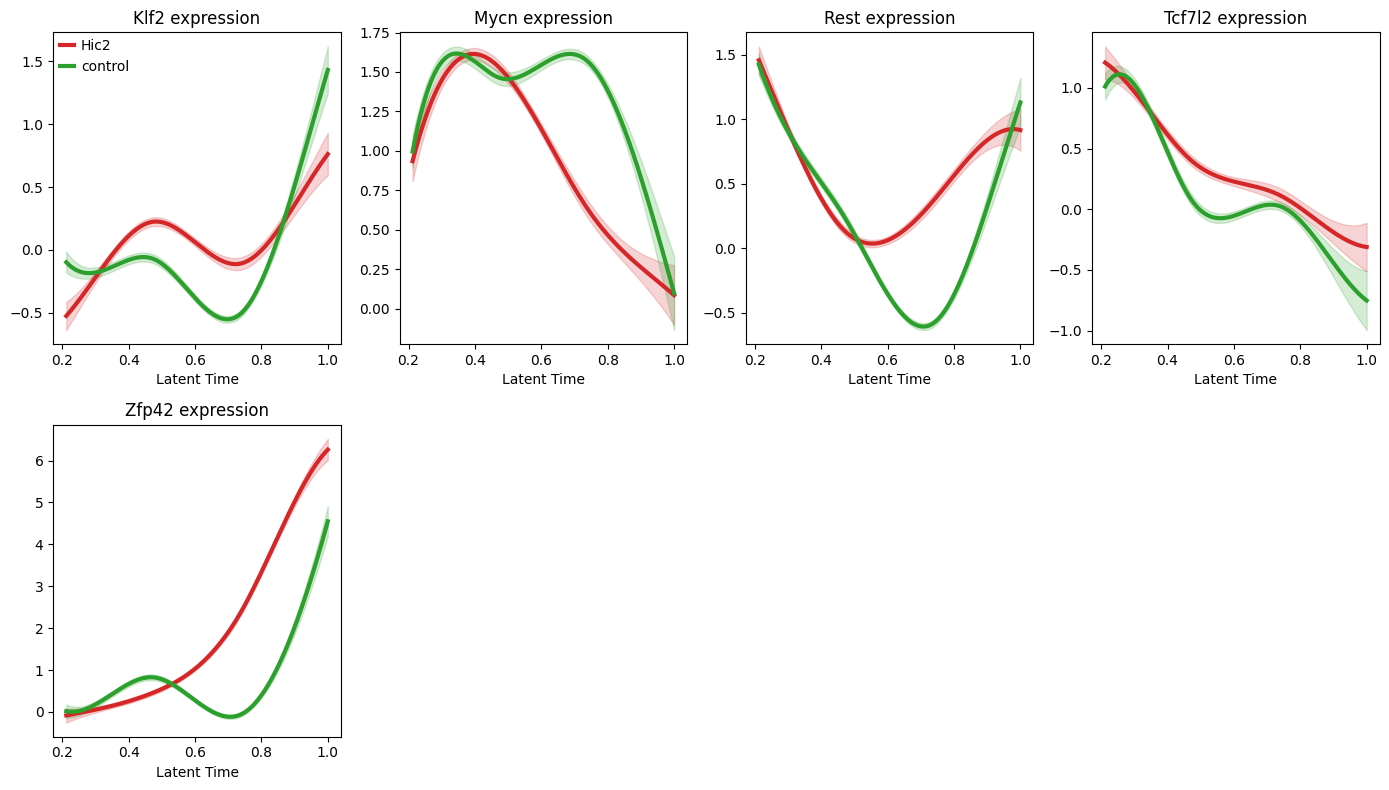

In [60]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Jarid2 and Zfp42 activities follow almost the exact same trends as their mRNA levels. They are similar until Hic2 and control cells start to take different trajectories. Rest has similar trends as its mRNA expression.

In [61]:
# Load another library
net = load_enrichr_as_network('TF_Perturbations_Followed_by_Expression') # Has the most genes because it is a collection

2026-02-05 14:05:45 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-05 14:05:45 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.TF_Perturbations_Followed_by_Expression.gmt, use local file


In [62]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-05 14:05:46 | [INFO] ulm - Running ulm
2026-02-05 14:05:46 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-05 14:05:46 | [INFO] Network adjacency matrix has 1749 unique features and 342 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-05 14:05:46 | [INFO] ulm - fitting 342 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-05 14:05:48 | [INFO] ulm - adjusting p-values by FDR
2026-02-05 14:05:48 | [INFO] ulm - done


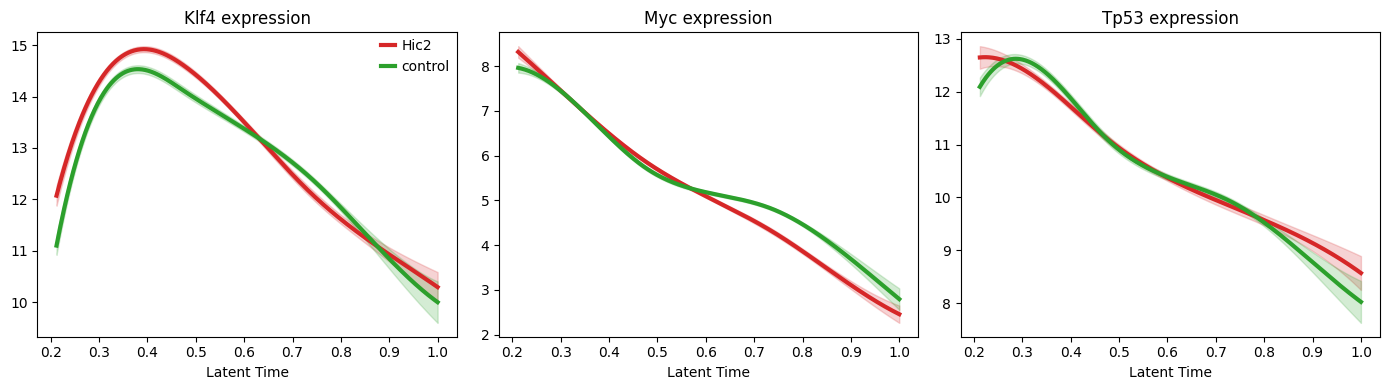

In [63]:
# Activity of interesting genes

plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Tp53"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

In [114]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

NameError: name 'dead_end_tfs' is not defined

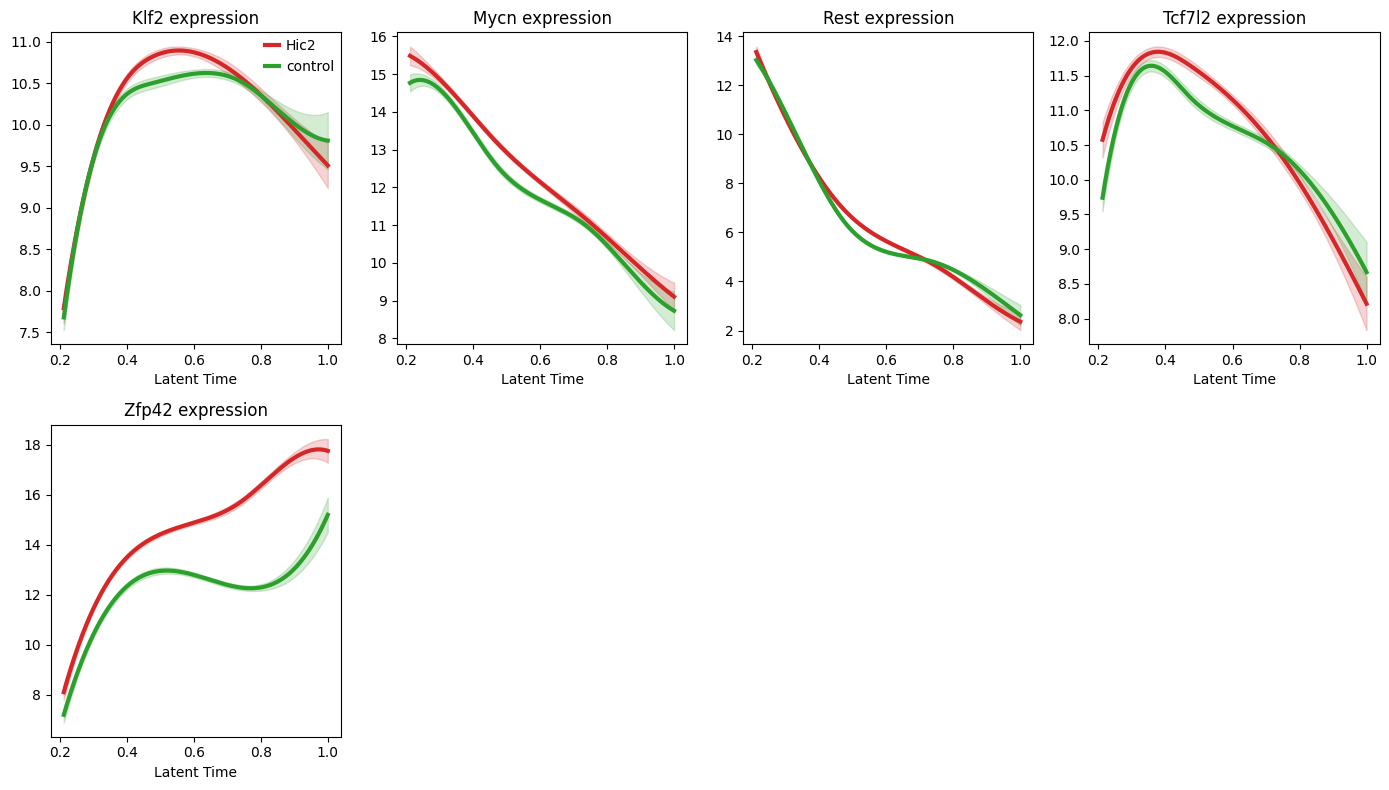

In [65]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

In [66]:
# Cellrank gene trends for dead end

import scanpy as sc
import cellrank as cr

def plot_tf_trends(adata, tfs, time_key, model=None, group_key="group"):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # Extract the ULM scores (Cell x TF matrix)
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = sc.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # Setup the CellRank model if not provided
    if model is None:
        model = cr.models.GAMR(tf_adata)
        
    # Plot using the standard function
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    lineages = ["mESC", "Day 12 Control"],
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

2026-02-05 14:05:49 | [INFO] cffi mode is CFFI_MODE.ANY


2026-02-05 14:05:50 | [INFO] R home found: /home/avesta/m26_losu/miniconda3/envs/velocity/lib/R
2026-02-05 14:05:50 | [INFO] R library path: 
2026-02-05 14:05:50 | [INFO] LD_LIBRARY_PATH: 
2026-02-05 14:05:50 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-02-05 14:05:50 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/avesta/m26_losu", R: "/home/avesta/m26_losu/hic2_masters_project"
2026-02-05 14:05:51 | [INFO] R is already initialized. No need to initialize.


  0%|          | 0/3 [00:00<?, ?gene/s]

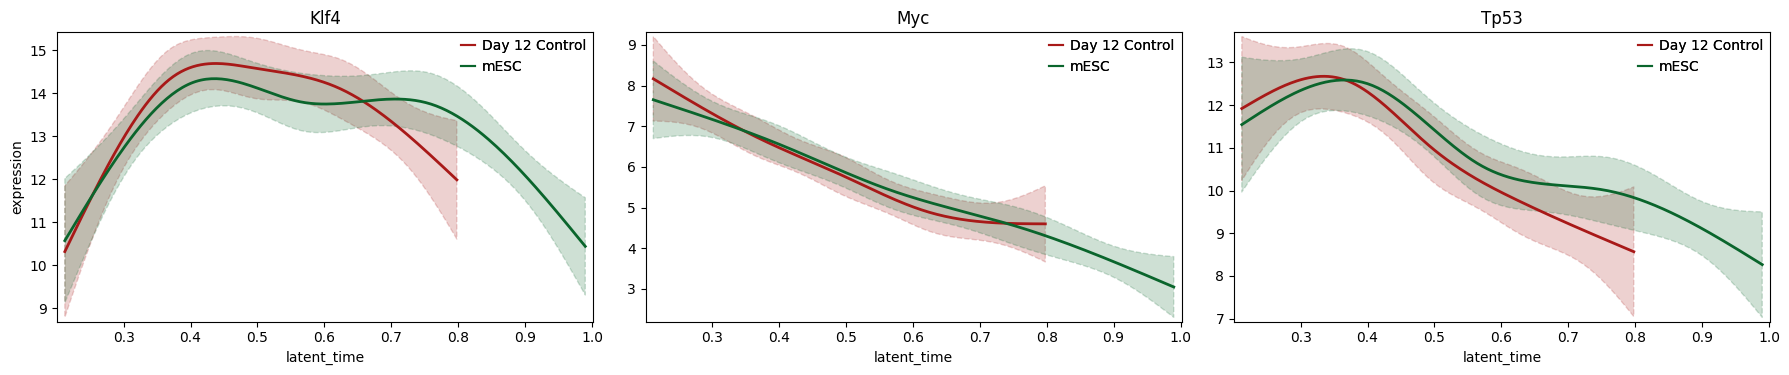

In [67]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(["Klf4", "Myc", "Tp53"], adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/2 [00:00<?, ?gene/s]

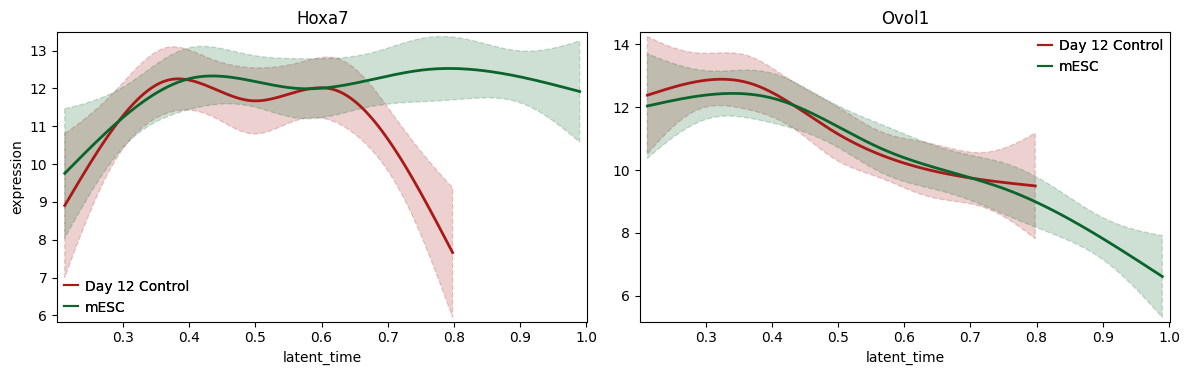

In [68]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/5 [00:00<?, ?gene/s]

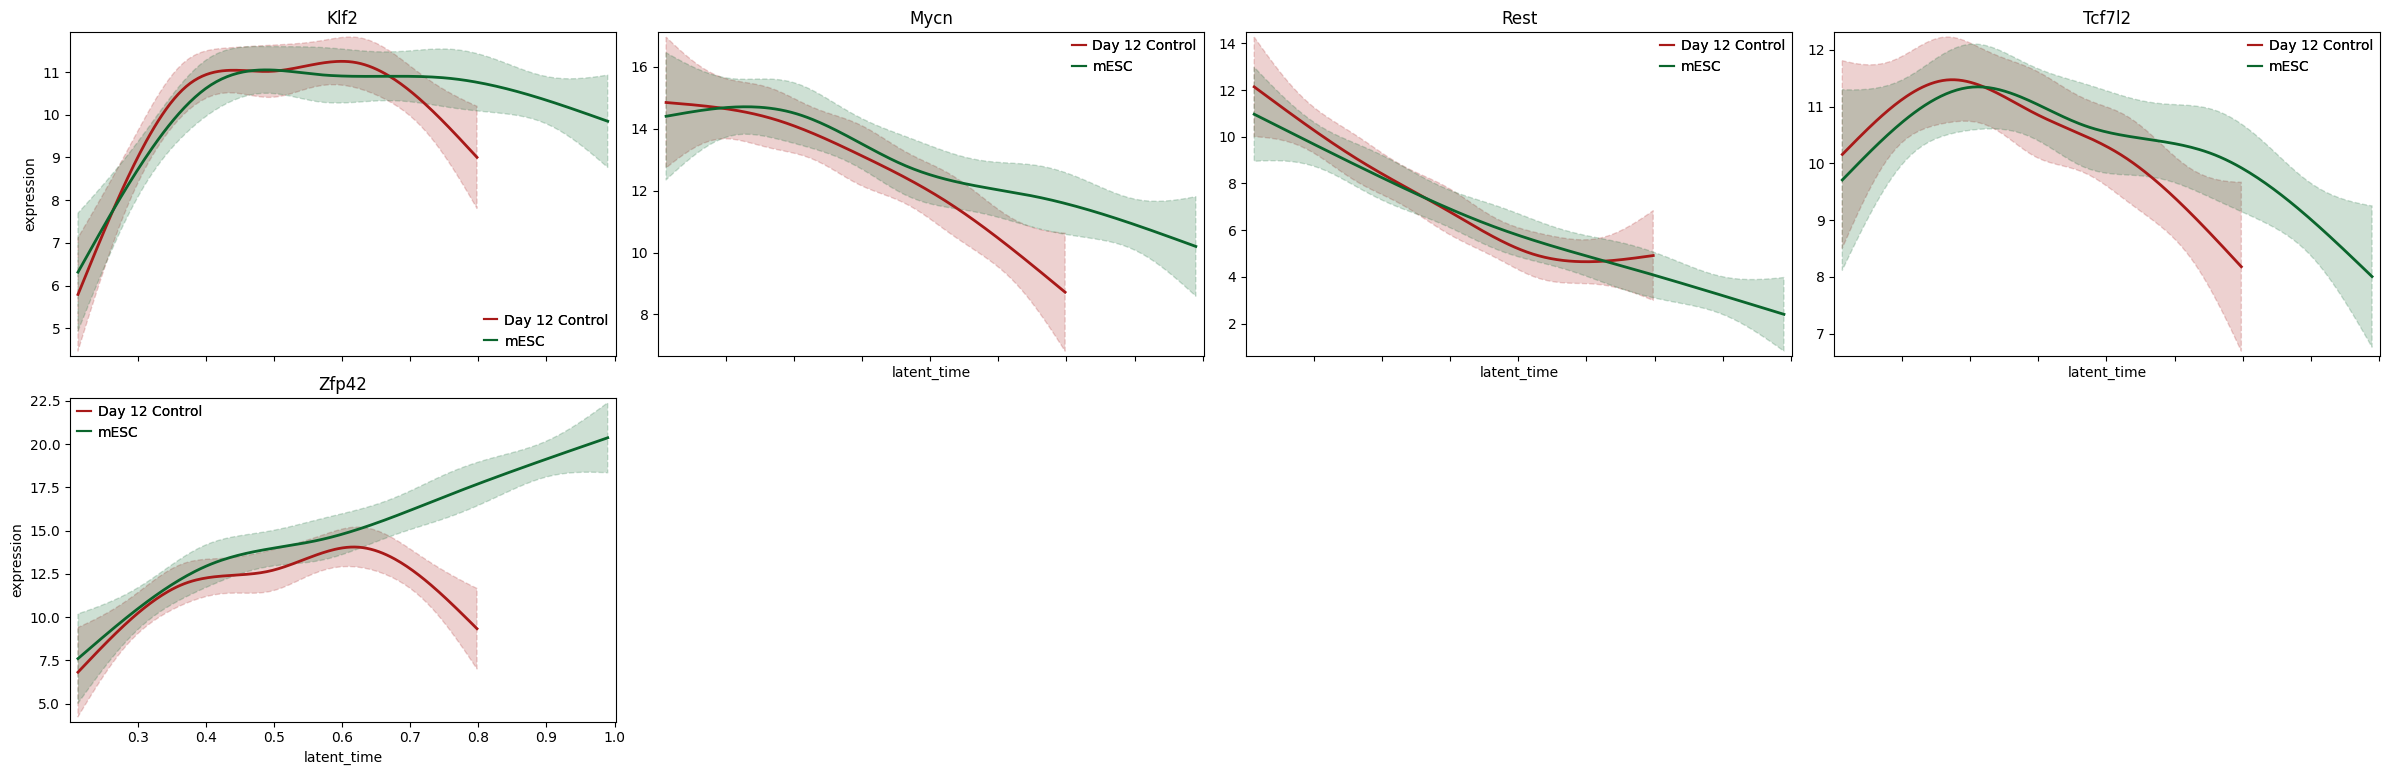

In [69]:
# Cellrank gene trends for stem cells

plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Zfp42 activity is interesting, as it increases in the mESC cells. The other genes do not look like clear reprogramming drivers.

In [70]:
# A library from CRISPR screen
net = load_enrichr_as_network('PerturbSeq_ReplogleK562')

# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-05 14:05:56 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-05 14:06:05 | [INFO] ulm - Running ulm
2026-02-05 14:06:05 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-05 14:06:06 | [INFO] Network adjacency matrix has 499 unique features and 1477 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-05 14:06:06 | [INFO] ulm - fitting 1477 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-05 14:06:10 | [INFO] ulm - adjusting p-values by FDR
2026-02-05 14:06:10 | [INFO] ulm - done


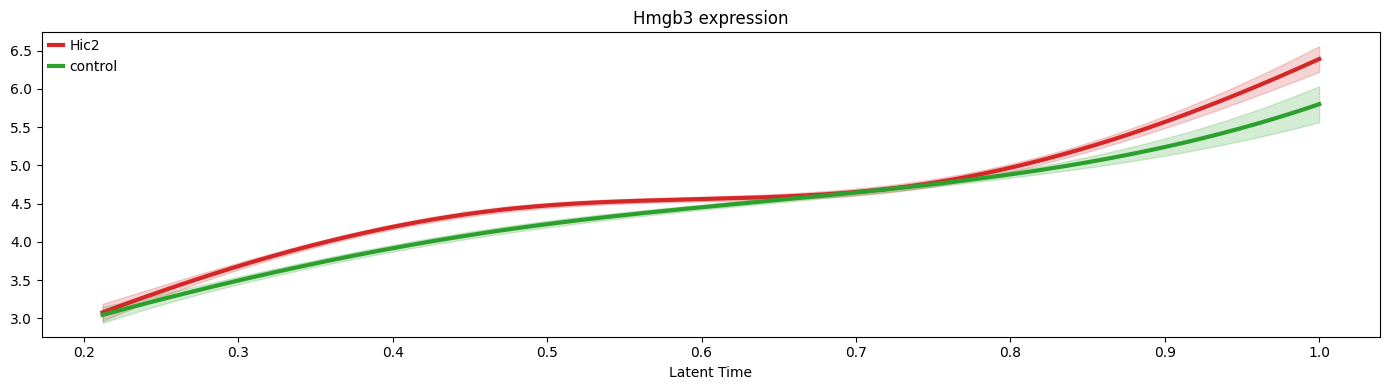

In [71]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

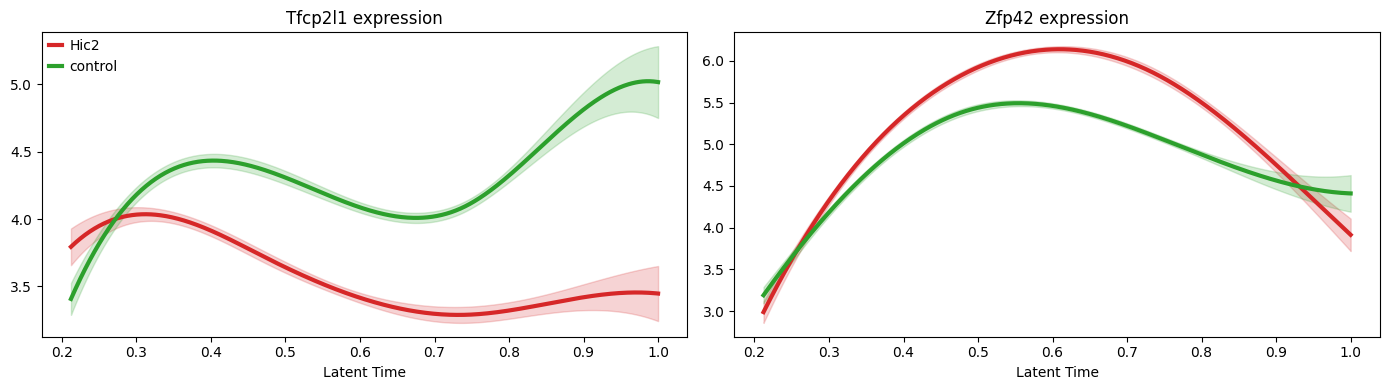

In [72]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

# Conclusions

The most important target of Hic2 is Ovol1. It downregulates c-Myc (https://www.nature.com/articles/modpathol2016169) and inhibits the epithelial to mesenchymal transition by degrading the TGF-β receptor type 1 while promoting mesenchymal-to-epithelial transition (https://www.nature.com/articles/s41392-022-00944-w).